| Step | Name | What You Do | Key Equation | Purpose | Source |
|------|------|------------|-------------|--------|--------|
| 1 | Estimate VAR | Fit VAR(p) using OLS | $ Y_t = \sum_{\ell=1}^p A_\ell Y_{t-\ell} + u_t $ | Capture dynamic relationships | Sims (1980); Lütkepohl (2005) |
| 2 | Wold Innovations | Define unpredictable component | $ m_t = Y_t - \mathbb{E}[Y_t \mid Y_{t-1}, Y_{t-2}, \dots] $ | Obtain VAR innovations | Wold (1938); Stock & Watson (2018) |
| 3 | Structural Mapping | Link innovations to structural shocks | $ m_t = \Theta_0 \varepsilon_t $ | Define economic shocks | Sims (1980); Stock & Watson (2018) |
| 4 | Identification | Use restrictions or external instruments (IV) | $ \Sigma_m = \Theta_0 \Theta_0' $ or IV moments | Recover causal shocks | Sims (1980); Stock & Watson (2018); Mertens & Ravn (2013) |
| 5 | Invert VAR | Compute MA representation | $ C(L) = A(L)^{-1} $ | Describe propagation over time | Lütkepohl (2005); Kilian & Lütkepohl (2017) |
| 6 | Structural MA | Express system in shocks | $ Y_t = C(L)\Theta_0 \varepsilon_t $ | Full dynamic causal system | Kilian & Lütkepohl (2017); Stock & Watson (2018) |
| 7 | Impulse Responses (IRFs) | Compute responses to shocks | $ \Theta_h = C_h \Theta_0 $ | Trace dynamic effects | Sims (1980); Stock & Watson (2018) |
| 8 | Variance Decomposition (FEVD) | Decompose forecast variance | Based on $ \Theta_h $ | Measure importance of shocks | Lütkepohl (2005); Kilian & Lütkepohl (2017) |

### References

- Sims, C. A. (1980). *Macroeconomics and Reality*. Econometrica.  
- Wold, H. (1938). *A Study in the Analysis of Stationary Time Series*.  
- Lütkepohl, H. (2005). *New Introduction to Multiple Time Series Analysis*.  
- Kilian, L., & Lütkepohl, H. (2017). *Structural Vector Autoregressive Analysis*.  
- Stock, J. H., & Watson, M. W. (2018). *Identification and Estimation of Dynamic Causal Effects in Macroeconomics*.  
- Mertens, K., & Ravn, M. (2013). *The Dynamic Effects of Personal and Corporate Income Tax Changes*. AER.

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 1: Estimate Reduced-Form VAR
</h2>

We begin by estimating the reduced-form VAR using OLS:

$$
Y_t = \sum_{\ell=1}^p A_\ell Y_{t-\ell} + u_t
$$

---

### Interpretation

- $Y_t$: vector of observed variables (e.g., output, inflation, interest rate)  
- $A_\ell$: coefficient matrices capturing dynamic relationships  
- $u_t$: reduced-form residuals  

---

### Key Properties

- Each variable depends on:
  - its own past  
  - the past of other variables  

- The model captures:
  - **dynamic relationships**
  - **correlations across variables**

- The residuals satisfy:
$$
\mathbb{E}[u_t \mid Y_{t-1}, Y_{t-2}, \dots] = 0
$$

---

### Estimation

- Each equation is estimated separately using **OLS**
- This is valid because all regressors are **lagged variables**

---

### Important Limitation

The residuals $u_t$ are **not structural shocks**:

$$
\mathbb{E}[u_t u_t'] = \Sigma_u \neq I
$$

- They are correlated across equations  
- They are mixtures of underlying economic shocks  

---

### Intuition

The reduced-form VAR tells us:

> “How variables evolve over time and respond to past information”

but not:

> “What are the underlying economic shocks driving these movements”

---

### Link to Next Step

We now isolate the **unpredictable component (innovations)**:

$$
m_t = Y_t - \mathbb{E}[Y_t \mid Y_{t-1}, Y_{t-2}, \dots]
$$

which will be used to define structural shocks.

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# -----------------------------
# 1. Generate synthetic VAR(1) data
# -----------------------------
np.random.seed(42)

T = 200  # number of observations
k = 3    # number of variables

# True VAR(1) coefficient matrix
A = np.array([
    [0.5, 0.1, 0.0],
    [0.2, 0.4, 0.1],
    [0.0, 0.3, 0.3]
])

# Generate shocks (correlated)
cov_u = np.array([
    [1.0, 0.5, 0.2],
    [0.5, 1.0, 0.3],
    [0.2, 0.3, 1.0]
])

u = np.random.multivariate_normal(mean=np.zeros(k), cov=cov_u, size=T)

# Initialize data
Y = np.zeros((T, k))

# Simulate VAR(1)
for t in range(1, T):
    Y[t] = A @ Y[t-1] + u[t]

# Convert to DataFrame
df = pd.DataFrame(Y, columns=["y1", "y2", "y3"])

# -----------------------------
# 2. Estimate VAR
# -----------------------------
model = VAR(df)
results = model.fit(1)  # VAR(1)

# -----------------------------
# 3. Output results
# -----------------------------

# Coefficient matrix A_hat
print("Estimated Coefficients (A):")
print(results.coefs)

# Residuals (u_t)
print("\nFirst 5 residuals:")
print(results.resid.head())

# Covariance of residuals
print("\nCovariance matrix Σ_u:")
print(results.sigma_u)

Estimated Coefficients (A):
[[[ 0.48110519  0.00504766  0.09336321]
  [ 0.15853334  0.46903249  0.01113588]
  [-0.03235017  0.2779771   0.32172821]]]

First 5 residuals:
         y1        y2        y3
1 -1.286193 -1.109085 -0.827956
2 -1.091325 -0.902818 -1.738846
3 -0.714836 -0.360499 -0.143468
4 -1.728443  0.362866  1.008264
5  0.122480  0.184092  0.985524

Covariance matrix Σ_u:
          y1        y2        y3
y1  0.870284  0.374133  0.153182
y2  0.374133  0.823007  0.178403
y3  0.153182  0.178403  1.001249


<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 2: Define Wold Innovations
</h2>

After estimating the VAR, we define the **innovations** (unpredictable component of the data):

$$
m_t = Y_t - \mathbb{E}[Y_t \mid Y_{t-1}, Y_{t-2}, \dots]
$$

---

### Interpretation

- $m_t$: innovations (forecast errors)  
- They represent the **new information at time $t$**  
- They cannot be predicted using past data  

---

### Key Property

The innovations satisfy:

$$
\mathbb{E}[m_t \mid \text{past}] = 0
$$

---

### Connection to VAR Residuals

In a correctly specified VAR:

$$
m_t = u_t
$$

- The residuals from Step 1 are exactly the **Wold innovations**  
- This gives them a clear economic interpretation as **unexpected movements**

---

### Important Feature

The innovations are generally **correlated across variables**:

$$
\mathbb{E}[m_t m_t'] = \Sigma_m \neq I
$$

- They are not independent  
- They combine multiple underlying shocks  

---

### Intuition

This step isolates:

> “What is new in the system at time $t$ that could not be predicted from the past”

---

### Link to Next Step

We now decompose these innovations into **structural shocks**:

$$
m_t = \Theta_0 \varepsilon_t
$$

where $\varepsilon_t$ are economically interpretable shocks.

First 5 innovations (m_t):
         y1        y2        y3
1 -1.286193 -1.109085 -0.827956
2 -1.091325 -0.902818 -1.738846
3 -0.714836 -0.360499 -0.143468
4 -1.728443  0.362866  1.008264
5  0.122480  0.184092  0.985524

Mean of innovations:
y1    2.359921e-16
y2    1.115802e-18
y3    1.087907e-16
dtype: float64

Covariance matrix of innovations:
          y1        y2        y3
y1  0.870284  0.374133  0.153182
y2  0.374133  0.823007  0.178403
y3  0.153182  0.178403  1.001249


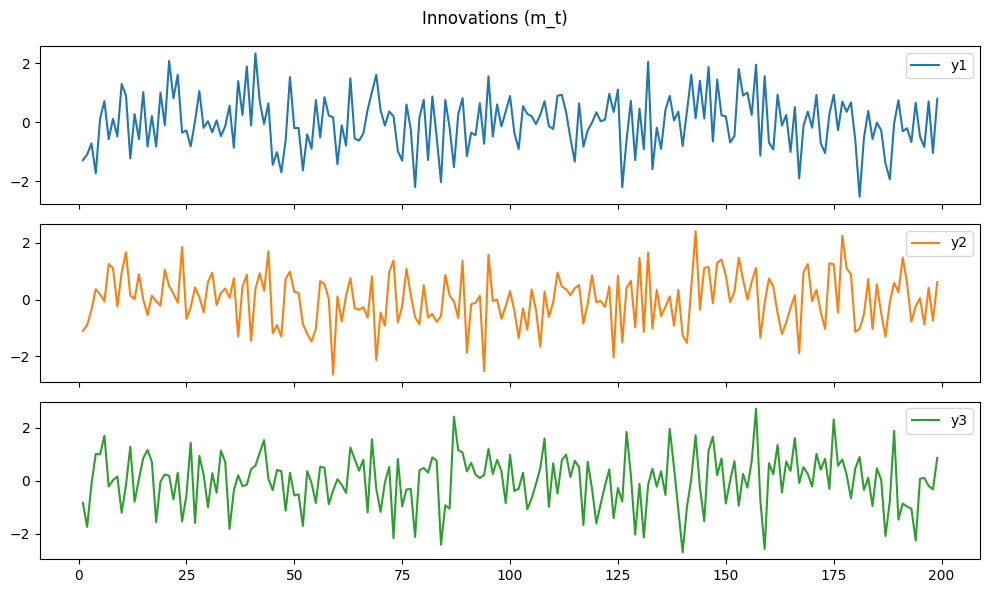

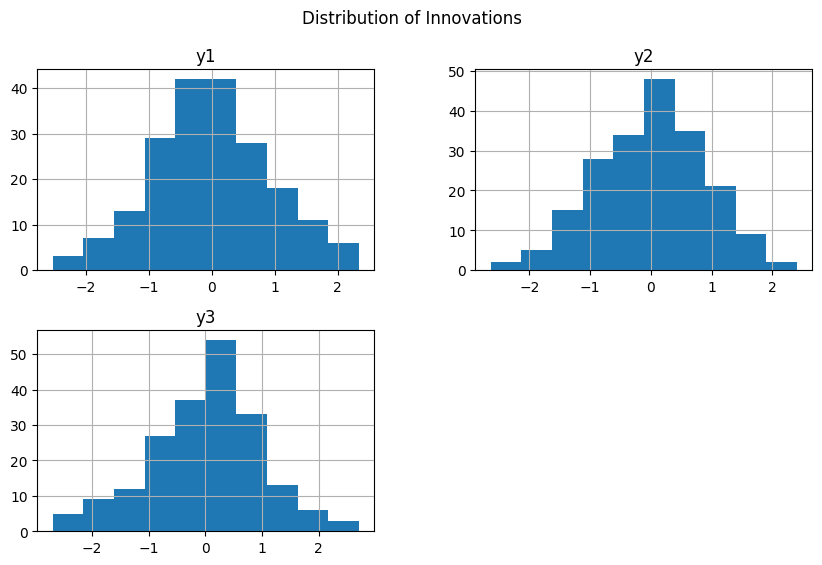


Correlation matrix of innovations:
          y1        y2        y3
y1  1.000000  0.442072  0.164099
y2  0.442072  1.000000  0.196531
y3  0.164099  0.196531  1.000000


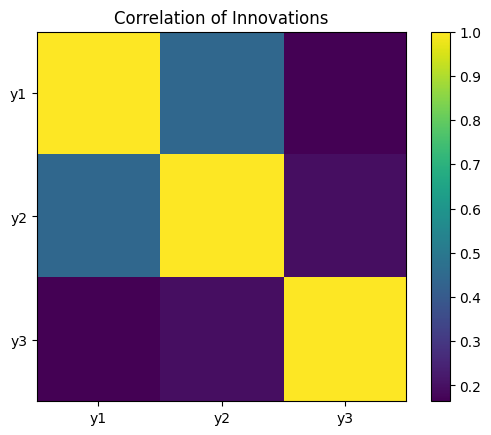

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# -----------------------------
# 1. Generate synthetic data (same as before)
# -----------------------------
np.random.seed(42)

T = 200
k = 3

A = np.array([
    [0.5, 0.1, 0.0],
    [0.2, 0.4, 0.1],
    [0.0, 0.3, 0.3]
])

cov_u = np.array([
    [1.0, 0.5, 0.2],
    [0.5, 1.0, 0.3],
    [0.2, 0.3, 1.0]
])

u = np.random.multivariate_normal(np.zeros(k), cov_u, size=T)

Y = np.zeros((T, k))
for t in range(1, T):
    Y[t] = A @ Y[t-1] + u[t]

df = pd.DataFrame(Y, columns=["y1", "y2", "y3"])

# -----------------------------
# 2. Estimate VAR
# -----------------------------
model = VAR(df)
results = model.fit(1)

# -----------------------------
# 3. Extract innovations (m_t = u_t)
# -----------------------------
innovations = results.resid

print("First 5 innovations (m_t):")
print(innovations.head())

# -----------------------------
# 4. Check mean ~ 0
# -----------------------------
print("\nMean of innovations:")
print(innovations.mean())

# -----------------------------
# 5. Covariance matrix Σ_m
# -----------------------------
print("\nCovariance matrix of innovations:")
print(results.sigma_u)

# -----------------------------
# 6. Plot innovations (time series)
# -----------------------------
innovations.plot(subplots=True, figsize=(10, 6), title="Innovations (m_t)")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Histogram (distribution)
# -----------------------------
innovations.hist(figsize=(10, 6))
plt.suptitle("Distribution of Innovations")
plt.show()

# -----------------------------
# 8. Correlation matrix
# -----------------------------
corr = innovations.corr()
print("\nCorrelation matrix of innovations:")
print(corr)

# Heatmap (simple)
plt.imshow(corr, interpolation='none')
plt.colorbar()
plt.xticks(range(k), innovations.columns)
plt.yticks(range(k), innovations.columns)
plt.title("Correlation of Innovations")
plt.show()

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 3: Structural Mapping
</h2>

We now decompose the innovations into **structural shocks**:

$$
m_t = \Theta_0 \varepsilon_t
$$

---

### Interpretation

- $m_t$: innovations from Step 2 (reduced-form shocks)  
- $\varepsilon_t$: **structural shocks** (economically meaningful)  
- $\Theta_0$: contemporaneous impact matrix  

---

### Key Assumption

The structural shocks satisfy:

$$
\mathbb{E}[\varepsilon_t \varepsilon_t'] = I
$$

- Shocks are **uncorrelated**
- Each shock represents a **distinct economic force**

---

### Why This Step is Needed

From Step 2:

$$
\mathbb{E}[m_t m_t'] = \Sigma_m \neq I
$$

- Innovations are **correlated**
- They mix multiple underlying shocks  

This step separates them into **independent components**.

---

### Mathematical Implication

From the mapping:

$$
\Sigma_m = \mathbb{E}[m_t m_t'] = \Theta_0 \Theta_0'
$$

- The covariance of innovations determines $\Theta_0$  
- But $\Theta_0$ is **not unique**

---

### Identification Problem

There are infinitely many matrices $\Theta_0$ such that:

$$
\Sigma_m = \Theta_0 \Theta_0'
$$

 Therefore, we need additional **economic assumptions** to identify the model.

---

### Intuition

This step answers:

> “What are the fundamental shocks driving the system?”

Instead of:
- mixed statistical innovations  

we obtain:
- **clean, interpretable economic shocks**

---

### Link to Next Step

To uniquely determine $\Theta_0$, we impose **identification restrictions**:

- Cholesky decomposition  
- Sign restrictions  
- External instruments (IV)  

These methods define how shocks affect variables contemporaneously.

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 4: Identification
</h2>

To recover structural shocks, we must identify the matrix $\Theta_0$ in:

$$
m_t = \Theta_0 \varepsilon_t
$$

---

### The Identification Problem

From Step 3:

$$
\Sigma_m = \mathbb{E}[m_t m_t'] = \Theta_0 \Theta_0'
$$

However, this decomposition is **not unique**:

- There are infinitely many matrices $\Theta_0$ satisfying this equation  
- Additional restrictions are required  

---

### Identification Strategies

#### 1. Recursive Identification (Cholesky)

Assume $\Theta_0$ is **lower triangular**:

$$
\Sigma_m = B B'
$$

- $B$ is obtained via **Cholesky decomposition**  
- Implies an ordering of variables  
- Variables earlier in the ordering do not respond contemporaneously to later ones  

---

#### 2. Sign Restrictions

Impose restrictions on the **sign of responses**:

- For example:
  - Monetary policy shock → interest rate increases  
- Allows more flexibility than Cholesky  

---
#### 3. External Instruments (SVAR-IV)

Use an instrument $Z_t$ correlated with one structural shock:

$$
\mathbb{E}[m_t Z_t] = \Theta_0 \begin{pmatrix} a \\ 0 \end{pmatrix}
$$

- Identifies a specific structural shock  
- Does not require ordering assumptions  
- Relies on **instrument validity** (relevance + exogeneity)

**High-Frequency (HF) Identification:**
- Constructs $Z_t$ using **high-frequency surprises** around announcements (e.g., FOMC)  
- Assumes only one shock is active in a narrow time window  
- Provides a **credible and widely used instrument** for SVAR-IV / LP-IV  

HF is a practical way to build external instruments

### Output of Identification

Once $\Theta_0$ is identified, we can recover structural shocks:

$$
\varepsilon_t = \Theta_0^{-1} m_t
$$

---

### Intuition

Identification answers:

> “How do we separate observed innovations into economically meaningful shocks?”

Different methods reflect different **economic assumptions**.

---

### Link to Next Step

With $\Theta_0$ identified, we can study how shocks affect the system over time using:

$$
Y_t = C(L)\Theta_0 \varepsilon_t
$$

This leads to the computation of **impulse response functions (IRFs)**.



$u_t$ is the estimated residual, $m_t$ is its interpretation as the true innovation—and in a correctly specified VAR, they are the same.


Theta_0 (Cholesky factor):
[[0.93288993 0.         0.        ]
 [0.40104691 0.8137371  0.        ]
 [0.16420174 0.1383135  0.9773207 ]]

First 5 structural shocks:
     shock1    shock2    shock3
0 -1.378719 -0.683457 -0.518802
1 -1.169833 -0.532924 -1.507230
2 -0.766260 -0.065368 -0.008805
3 -1.852784  1.359062  1.150613
4  0.131291  0.161524  0.963475


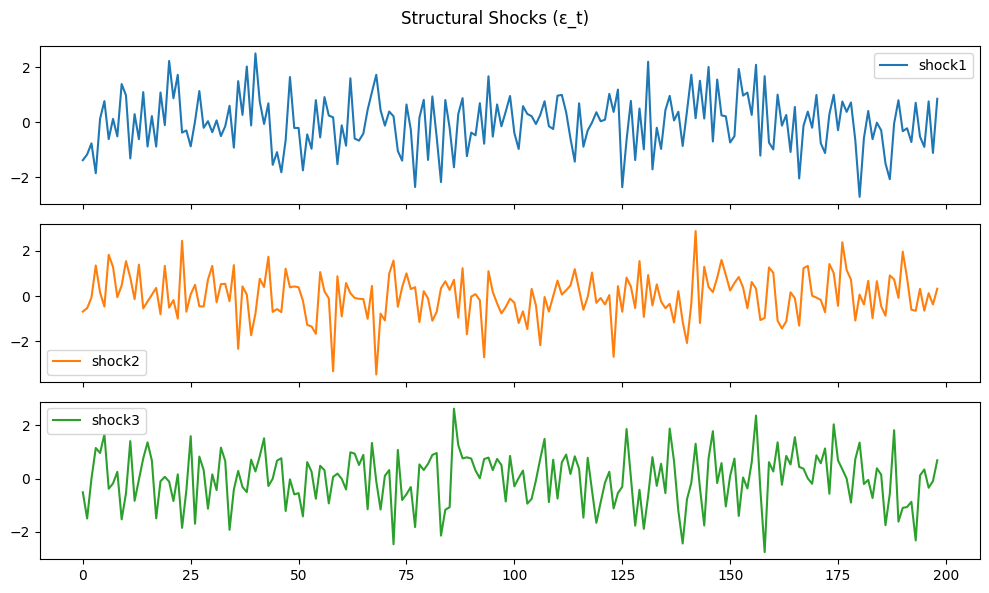


Covariance of structural shocks (should be close to I):
[[ 9.84848485e-01 -2.33258979e-16  2.24287480e-18]
 [-2.33258979e-16  9.84848485e-01 -1.07657990e-16]
 [ 2.24287480e-18 -1.07657990e-16  9.84848485e-01]]


In [6]:
# -----------------------------
# Step 3: Structural Mapping (conceptual)
# -----------------------------
# m_t = Θ0 ε_t  (we now estimate Θ0 via identification)

# Convert innovations to numpy array (k x T)
m = innovations.values.T

# -----------------------------
# Step 4: Identification (Cholesky)
# -----------------------------
# Σ_m = Θ0 Θ0'
Sigma = results.sigma_u

# Cholesky decomposition → Θ0
Theta_0 = np.linalg.cholesky(Sigma)

print("\nTheta_0 (Cholesky factor):")
print(Theta_0)

# -----------------------------
# Recover structural shocks ε_t
# -----------------------------
eps = np.linalg.inv(Theta_0) @ m

# Convert to DataFrame for plotting
eps_df = pd.DataFrame(eps.T, columns=["shock1", "shock2", "shock3"])

print("\nFirst 5 structural shocks:")
print(eps_df.head())

# -----------------------------
# Plot structural shocks
# -----------------------------
eps_df.plot(subplots=True, figsize=(10, 6), title="Structural Shocks (ε_t)")
plt.tight_layout()
plt.show()

# -----------------------------
# Check covariance of shocks
# -----------------------------
print("\nCovariance of structural shocks (should be close to I):")
print(np.cov(eps))

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 5: Invert VAR (MA Representation)
</h2>

**Turning a system of equations into a shock propagation machine**

After identifying structural shocks, we rewrite the VAR as a function of current and past shocks.

---

### Start from the reduced-form VAR

$$
Y_t = \sum_{\ell=1}^p A_\ell Y_{t-\ell} + m_t
$$

---

### Rewrite using the lag operator

Define the lag polynomial:
$$
A(L) = I - A_1 L - A_2 L^2 - \cdots - A_p L^p
$$

Then:
$$
A(L) Y_t = m_t
$$

---

### Invert the system

If the VAR is stable, we can invert $A(L)$:

$$
Y_t = A(L)^{-1} m_t
$$

Let:
$$
C(L) = A(L)^{-1}
$$

---

### Moving Average (MA) representation

Expand $C(L)$ as an infinite series:

$$
Y_t = C(L) m_t = \sum_{h=0}^{\infty} C_h m_{t-h}
$$

**Explanation:**  
$C(L)$ is a polynomial in the lag operator:
$$
C(L) = C_0 + C_1 L + C_2 L^2 + \cdots
$$

Applying it:
$$
C(L)m_t = C_0 m_t + C_1 m_{t-1} + C_2 m_{t-2} + \cdots
$$

---

### Interpretation of $C_h$

- $C_h$ measures the effect of a shock at time $t-h$ on $Y_t$:
$$
C_h = \frac{\partial Y_t}{\partial m_{t-h}}
$$

👉 So $C_h$ is the **impulse response coefficient** at horizon $h$

---
### Interpretation of $C_h$

- $C_h$ measures the effect of a shock at time $t-h$ on $Y_t$:
$$
C_h = \frac{\partial Y_t}{\partial m_{t-h}}
$$

So $C_h$ is the **impulse response coefficient** at horizon $h$

---

### From derivatives to recursion

We also have:
$$
C(L)A(L)=I
$$

with:
$$
C(L)=\sum_{h=0}^\infty C_h L^h, \quad A(L)=I-\sum_{\ell=1}^p A_\ell L^\ell
$$

Multiply:
$$
\left(\sum_{h=0}^\infty C_h L^h \right)
\left(I-\sum_{\ell=1}^p A_\ell L^\ell \right)=I
$$

---

### Match coefficients of $L^h$

- For $h=0$:
$$
C_0 = I
$$

- For $h \ge 1$:
$$
C_h - \sum_{\ell=1}^p A_\ell C_{h-\ell} = 0
$$

Rearrange:
$$
C_h = \sum_{\ell=1}^{\min(h,p)} A_\ell C_{h-\ell}
$$

---

### Intuition

- The **derivative definition** tells you what $C_h$ means  
- The **recursion** shows how to compute it  

Each $C_h$ is built by propagating past effects through the VAR coefficients.


---

### Intuition

- The **derivative definition** tells you what $C_h$ means (effect of a shock)  
- The **recursive formula** tells you how to compute it from the VAR  

👉 Each $C_h$ is built by propagating past effects through the VAR coefficients

**Why $\min(h,p)$?**
- Only $p$ lags exist in the VAR  
- At horizon $h$, only terms up to $h$ are available  

---

### Intuition

- $C_0$: immediate impact  
- $C_1$: one-period propagation  
- $C_2$: two-period propagation  

The system becomes:
> “a function of current and past shocks”

---

### Link to structural shocks

$$
Y_t = C(L)\Theta_0 \varepsilon_t
$$

This leads directly to **Impulse Response Functions (IRFs)**

---

### Big Picture

- **Step 4:** What the shocks are  
- **Step 5:** How shocks propagate  
- **Step 6:** Combine both to get causal responses

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 5: Invert VAR (MA Representation)
</h2>

**Turning a system of equations into a shock propagation machine**

After identifying structural shocks, we rewrite the VAR as a function of current and past shocks.

---

### Start from the reduced-form VAR

$$
Y_t = \sum_{\ell=1}^p A_\ell Y_{t-\ell} + m_t
$$

---

### Rewrite using the lag operator

Define the lag polynomial:
$$
A(L) = I - A_1 L - A_2 L^2 - \cdots - A_p L^p
$$

Then:
$$
A(L) Y_t = m_t
$$

---

### Invert the system

If the VAR is stable, we can invert $A(L)$:

$$
Y_t = A(L)^{-1} m_t
$$

Let:
$$
C(L) = A(L)^{-1}
$$

---

### Moving Average (MA) representation

Expand $C(L)$ as an infinite series:

$$
Y_t = C(L) m_t = \sum_{h=0}^{\infty} C_h m_{t-h}
$$

**Explanation:**  
$C(L)$ is a polynomial (infinite series) in the lag operator:
$$
C(L) = C_0 + C_1 L + C_2 L^2 + \cdots
$$

Applying it to $m_t$:
- $L m_t = m_{t-1}$
- $L^2 m_t = m_{t-2}$

So:
$$
C(L)m_t = C_0 m_t + C_1 m_{t-1} + C_2 m_{t-2} + \cdots
$$

which gives:
$$
\sum_{h=0}^{\infty} C_h m_{t-h}
$$

---

### Interpretation of $C_h$

- $C_h$ measures the effect of a shock at time $t-h$ on $Y_t$:
$$
C_h = \frac{\partial Y_t}{\partial m_{t-h}}
$$

👉 So $C_h$ is the **impulse response coefficient** at horizon $h$

---

### Deriving the recursion for $C_h$

We also have:
$$
C(L)A(L)=I
$$

with:
$$
C(L)=\sum_{h=0}^\infty C_h L^h, \quad A(L)=I-\sum_{\ell=1}^p A_\ell L^\ell
$$

Multiply:
$$
\left(\sum_{h=0}^\infty C_h L^h \right)
\left(I-\sum_{\ell=1}^p A_\ell L^\ell \right)=I
$$

---

### Match coefficients of $L^h$

- For $h=0$:
$$
C_0 = I
$$

- For $h \ge 1$:
$$
C_h - \sum_{\ell=1}^p A_\ell C_{h-\ell} = 0
$$

Rearrange:
$$
C_h = \sum_{\ell=1}^{\min(h,p)} A_\ell C_{h-\ell}
$$

---

### Intuition (derivation + meaning)

- The **derivative definition** tells you what $C_h$ means (effect of a shock)  
- The **recursive formula** tells you how to compute it from the VAR  

👉 Each $C_h$ is built by propagating past effects through the VAR coefficients

---

### Why $\min(h,p)$?

- Only $p$ lags exist in the VAR  
- At horizon $h$, only terms up to $h$ are available  

---

### Intuition (dynamics)

- $C_0$: immediate impact  
- $C_1$: one-period propagation  
- $C_2$: two-period propagation  

👉 The system becomes:
> “a function of current and past shocks”

---

### Link to structural shocks

$$
Y_t = C(L)\Theta_0 \varepsilon_t
$$

This leads directly to **Impulse Response Functions (IRFs)**

---

### Big Picture

- **Step 4:** What the shocks are  
- **Step 5:** How shocks propagate  
- **Step 6:** Combine both → causal responses


C_0:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

C_1:
[[ 0.48110519  0.00504766  0.09336321]
 [ 0.15853334  0.46903249  0.01113588]
 [-0.03235017  0.2779771   0.32172821]]

C_2:
[[0.22924211 0.03074881 0.07501131]
 [0.15026825 0.22388722 0.023607  ]
 [0.01809684 0.21965007 0.10358424]]


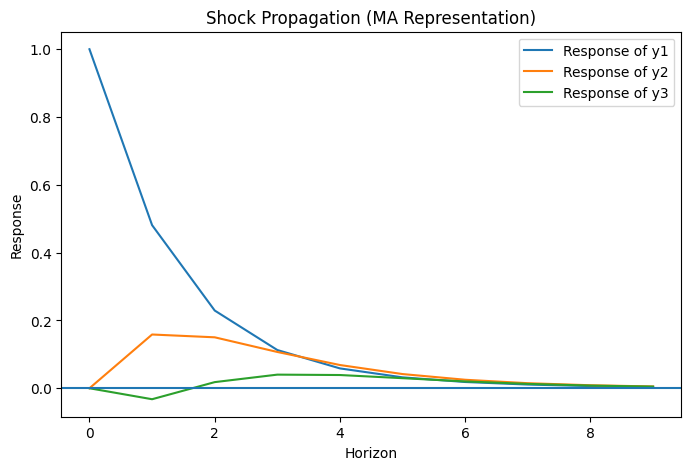

In [7]:
# -----------------------------
# Step 5: Compute MA coefficients (C_h)
# -----------------------------
A_hat = results.coefs[0]   # VAR(1) → A matrix
k = A_hat.shape[0]
H = 10  # horizon

# Initialize C_h
C = [np.eye(k)]  # C_0 = I

# Recursive computation
for h in range(1, H):
    C_h = A_hat @ C[h-1]
    C.append(C_h)

# -----------------------------
# Print first few C_h
# -----------------------------
for h in range(3):
    print(f"\nC_{h}:")
    print(C[h])

# -----------------------------
# Plot propagation of a shock
# -----------------------------
shock_index = 0  # shock to variable 1

responses = []

for h in range(H):
    response = C[h][:, shock_index]  # response of all variables
    responses.append(response)

responses = np.array(responses)

# Plot
plt.figure(figsize=(8, 5))

for i in range(k):
    plt.plot(responses[:, i], label=f"Response of y{i+1}")

plt.axhline(0)
plt.title("Shock Propagation (MA Representation)")
plt.xlabel("Horizon")
plt.ylabel("Response")
plt.legend()
plt.show()

### Interpretation of MA Representation

---

### Meaning of Matrix Elements

For any matrix $C_h$, each element $(i,j)$ represents:

> **the effect on variable $i$ from a shock in variable $j$ after $h$ periods**

- Row $i$ → responding variable  
- Column $j$ → shocked variable  

---

### Matrix Interpretation

- $C_0 = I$: a shock affects the variable itself immediately (impact = 1), with no cross-variable effects  
- $C_1, C_2, \dots$: show how shocks propagate across variables over time (including cross-effects)

---

### Plot Interpretation

- The plot shows the response of all variables to a **shock in $y_1$** (i.e., first column of $C_h$)

---

### Key Observations

- The effect on $y_1$ is strongest at impact and **decays over time**
- Other variables ($y_2$, $y_3$) respond with a **delay and smaller magnitude**
- All responses gradually **converge to zero**, indicating stability

---

### Intuition

> The system absorbs the shock over time, and its effect fades as it propagates through the dynamics.

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 6: Structural MA Representation
</h2>

Combining the MA representation (Step 5) with structural shocks (Step 4), we obtain:

$$
Y_t = C(L)\Theta_0 \varepsilon_t = \sum_{h=0}^{\infty} C_h \Theta_0 \varepsilon_{t-h}
$$

---

### Interpretation

- $C_h$: propagation of shocks over time  
- $\Theta_0$: contemporaneous impact  
- $\varepsilon_t$: structural shocks  

---


In [10]:
# Step 6 explicitly
Theta = []

for h in range(H):
    Theta_h = C[h] @ Theta_0
    Theta.append(Theta_h)

Theta = np.array(Theta)

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 7: Impulse Response Functions (IRFs)
</h2>

Impulse response functions measure how variables respond over time to a structural shock.

$$
\Theta_h = C_h \Theta_0
$$

---

### Interpretation

- $\Theta_h$: response of all variables at horizon $h$  
- Each column corresponds to a **shock**  
- Each row corresponds to a **variable**  

---

### Key Idea

IRFs trace the dynamic effect of a **one-unit structural shock** over time.

---

### Intuition

> “If a shock occurs today, how does it affect the system in future periods?”

---

### Important Properties

- At $h = 0$: immediate impact  
- At $h > 0$: propagation through system dynamics  
- Responses typically decay over time in stable systems  

---

### Link to Previous Steps

- Step 4: identifies shocks  
- Step 5: determines propagation  
- This step combines both  

---

### Output

IRFs are typically plotted to visualize:

- magnitude of responses  
- persistence of shocks  
- interactions across variables  

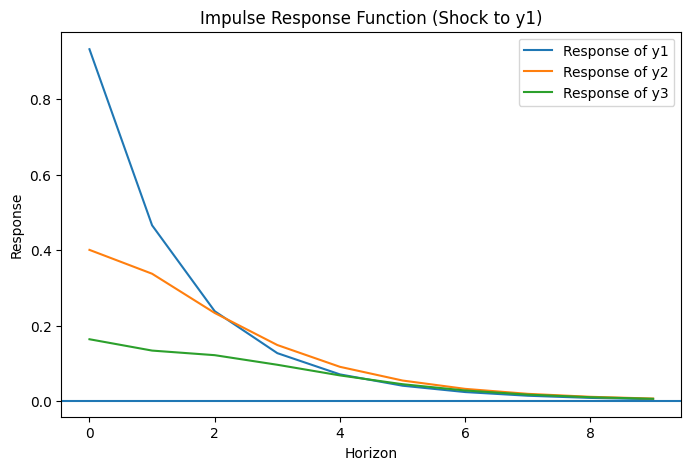

In [9]:
# -----------------------------
# Step 7: Compute IRFs
# -----------------------------
H = 10  # horizon

IRFs = []

for h in range(H):
    Theta_h = C[h] @ Theta_0
    IRFs.append(Theta_h)

IRFs = np.array(IRFs)

# -----------------------------
# Plot IRF: shock to variable 1
# -----------------------------
shock_index = 0

plt.figure(figsize=(8, 5))

for i in range(k):
    response = IRFs[:, i, shock_index]
    plt.plot(response, label=f"Response of y{i+1}")

plt.axhline(0)
plt.title("Impulse Response Function (Shock to y1)")
plt.xlabel("Horizon")
plt.ylabel("Response")
plt.legend()
plt.show()

### Interpretation of IRF (Shock to $y_1$)

- A shock to $y_1$ has a **large immediate effect** on itself, which **declines over time**
- $y_2$ and $y_3$ respond **positively but with smaller magnitude**
- The effects on all variables **gradually decay to zero**, indicating a stable system

---

### Key Insight

> The shock propagates across variables but its impact weakens over time and eventually disappears.

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 8: Forecast Error Variance Decomposition (FEVD)
</h2>

FEVD measures how much of the forecast error variance of each variable is explained by each structural shock.

---

### Definition

The $h$-step ahead forecast error is:

$$
Y_{t+h} - \mathbb{E}_t[Y_{t+h}] = \sum_{j=0}^{h-1} \Theta_j \varepsilon_{t+h-j}
$$

---

### Variance Decomposition

The contribution of shock $k$ to variable $i$ at horizon $h$ is:

$$
\text{FEVD}_{i,k}(h) =
\frac{
\sum_{j=0}^{h-1} \left( e_i' \Theta_j e_k \right)^2
}{
\sum_{j=0}^{h-1} e_i' \Theta_j \Theta_j' e_i
}
$$

---

### Interpretation

- $\text{FEVD}_{i,k}(h)$: fraction of variance of variable $i$ explained by shock $k$  
- Values lie between 0 and 1  
- Rows sum to 1 across shocks  

---

### Intuition

> “Which shocks are most important in driving each variable over time?”

---

### Key Insights

- At short horizons:
  - own shocks typically dominate  
- At longer horizons:
  - cross-variable effects may increase  

---

### Link to Previous Steps

- Step 4: identifies structural shocks  
- Step 7: provides dynamic responses ($\Theta_h$)  
- FEVD aggregates these effects into **variance contributions**

---

### Output

FEVD is typically reported as:

- tables (numerical contributions)  
- stacked bar plots (visual comparison across shocks)

FEVD for y1
           y1        y2        y3
0    1.000000  0.000000  0.000000
1    0.992141  0.000264  0.007595
2    0.986857  0.001330  0.011813
3    0.984271  0.002407  0.013323
4    0.983150  0.003069  0.013782
5    0.982699  0.003387  0.013915
6    0.982527  0.003519  0.013954
7    0.982464  0.003571  0.013966
8    0.982441  0.003590  0.013970
9    0.982433  0.003597  0.013971

FEVD for y2
           y1        y2        y3
0    0.195428  0.804572  0.000000
1    0.253634  0.746256  0.000109
2    0.280862  0.718583  0.000554
3    0.291860  0.707139  0.001001
4    0.295971  0.702754  0.001275
5    0.297451  0.701142  0.001407
6    0.297976  0.700562  0.001462
7    0.298162  0.700355  0.001483
8    0.298227  0.700282  0.001491
9    0.298251  0.700255  0.001494

FEVD for y3
           y1        y2        y3
0    0.026929  0.019107  0.953965
1    0.037732  0.077564  0.884704
2    0.047722  0.103433  0.848846
3    0.054147  0.111458  0.834395
4    0.057410  0.113631  0.828959
5    0.058

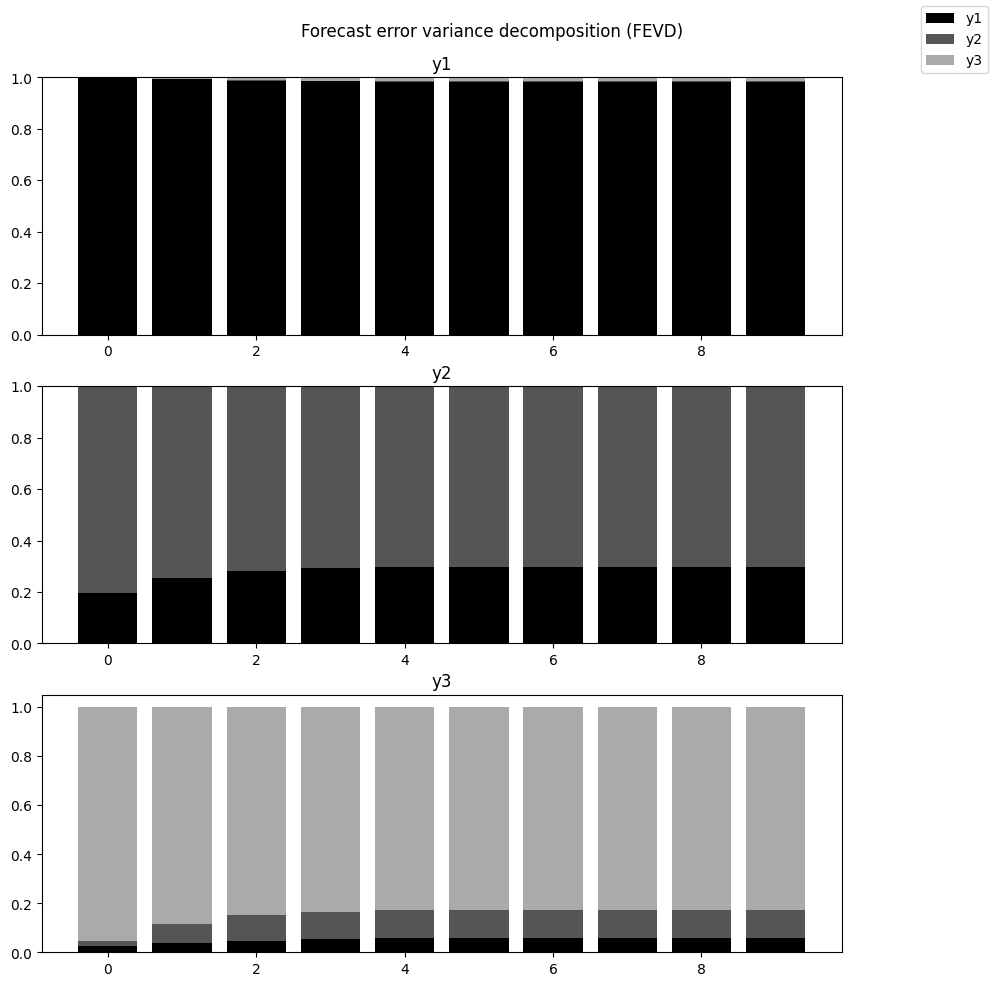

In [11]:
# -----------------------------
# Step 8: Forecast Error Variance Decomposition (FEVD)
# -----------------------------
H = 10  # horizon

# Compute FEVD
fevd = results.fevd(H)

# Print FEVD for each variable
print(fevd.summary())

# -----------------------------
# Plot FEVD
# -----------------------------
fevd.plot()
plt.show()

<h2 style="background-color: #D6EAF8; padding: 8px;">
Step 9: Comparison with Local Projections (LP)
</h2>

Local Projections (LP) provide an alternative method to estimate impulse responses without relying on VAR dynamics.

---

### LP Approach

Instead of estimating a VAR, LP directly estimates:

$$
Y_{t+h} = \alpha_h + \beta_h x_t + \Gamma_h Z_t + u_{t+h}
$$

---

### Interpretation

- $\beta_h$: impulse response at horizon $h$  
- $x_t$: shock (or instrumented shock)  
- $Z_t$: control variables (lags of $Y_t$)  

---

### Key Difference from VAR

| VAR | LP |
|-----|----|
| Estimates full system dynamics | Estimates each horizon separately |
| Uses recursion: $C_h$ | Directly estimates $\beta_h$ |
| Efficient if correctly specified | More robust to misspecification |

---

### Conceptual Difference

- VAR:
  > “Estimate dynamics → extrapolate forward” (trace the effect of a shock forward in time.)

- LP:
  > “Estimate response at each horizon directly”

---

### Identification

Both methods rely on the **same identification strategies**:

- Cholesky  
- Sign restrictions  
- External instruments (IV)  

---

### Advantages of LP

- Robust to model misspecification  
- Flexible  
- Easy to implement  

---

### Advantages of VAR

- More efficient if correctly specified  
- Imposes structure across horizons  

---

### Key Insight (from the paper)

> VAR and LP estimate the same impulse responses, but use different methods.

---

### When to Use Each

- Use VAR when:
  - model is well specified  
  - efficiency is important  

- Use LP when:
  - robustness is preferred  
  - model uncertainty is high  

<h2 style="background-color: #FDEDEC; padding: 8px;">
Appendix: Lag Operator and Polynomial Representation of VAR
</h2>

This appendix shows how the standard VAR representation can be written compactly using the lag operator.

---

### Starting Point

Consider the VAR($p$):

$$
Y_t = A_1 Y_{t-1} + A_2 Y_{t-2} + \cdots + A_p Y_{t-p} + m_t
$$

---

### Step 1: Rearranging

Move all lagged terms to the left-hand side:

$$
Y_t - A_1 Y_{t-1} - A_2 Y_{t-2} - \cdots - A_p Y_{t-p} = m_t
$$

---

### Step 2: Define the Lag Operator

The lag operator $L$ shifts variables backward in time:

$$
L Y_t = Y_{t-1}, \quad L^2 Y_t = Y_{t-2}, \quad \dots
$$

Using this notation:

$$
A_1 Y_{t-1} = A_1 L Y_t, \quad A_2 Y_{t-2} = A_2 L^2 Y_t
$$

An operator is something that acts on an object and changes it. 

L is like a “time machine” that moves your data to the past

---

### Step 3: Rewrite Using $L$

Substitute into the equation:

$$
Y_t - A_1 L Y_t - A_2 L^2 Y_t - \cdots - A_p L^p Y_t = m_t
$$

---

### Step 4: Factor Out $Y_t$

$$
(I - A_1 L - A_2 L^2 - \cdots - A_p L^p) Y_t = m_t
$$

---

### Step 5: Define the Polynomial

Define the matrix polynomial:

$$
A(L) = I - A_1 L - A_2 L^2 - \cdots - A_p L^p
$$

---

### Final Representation

$$
A(L) Y_t = m_t
$$

---

### Interpretation

- $A(L)$ summarizes all lag dynamics in one expression  
- The lag operator $L$ encodes time shifts  
- This representation is mathematically equivalent to the original VAR  

---

### Why This Matters

This compact form allows us to:

- Invert the system:
  $$
  Y_t = A(L)^{-1} m_t
  $$

- Derive the Moving Average (MA) representation:
  $$
  Y_t = \sum_{h=0}^{\infty} C_h m_{t-h}
  $$

---

### Key Insight

> The lag operator representation is simply a compact way of writing the VAR that makes further analysis (like inversion and impulse responses) much easier.

## <h2 style="background-color: #FDEDEC; padding: 8px;"> Appendix: Backward vs Forward Representation and the Role of
</h2>

 $C_h$


---

### Backward vs Forward Representation

- **Backward (MA):** explain the present using the past  
- **Forward (IRF):** trace the future effect of one shock  

---

### 🔹 1. Backward-looking (MA representation)

$$
Y_t = \sum_{h=0}^{\infty} C_h \varepsilon_{t-h}
$$

👉 This expression looks **backward in time**

- At time $t$, we collect **all past shocks**
- $\varepsilon_{t-h}$ = shock that happened $h$ periods ago  

**Today = current shock + past shocks + older shocks**


---

### 🔹 2. Forward-looking (Impulse Response view)

$$
Y_{t+h} = C_h \varepsilon_t
$$

👉 This expression looks **forward in time**

- We fix a shock at time $t$
- Then we track how this **same shock** affects the system over time  

- $h = 0$ → immediate (impact) effect  
- $h = 1$ → effect after one period  
- $h = 2$ → effect after two periods  
- $\dots$

We are **not summing over many shocks**.  
We are following **one shock as it propagates over time**.

`Shock at time t → effect today → effect tomorrow → effect later → fades out`

---

### 🔹 Role of $C_h$ in MA vs IRF

#### MA (Backward Representation)

$$
Y_t = \sum_{h=0}^{\infty} C_h \varepsilon_{t-h}
$$

- The index $h$ is **summed over**
- Each $C_h$ multiplies a **different shock** $\varepsilon_{t-h}$  

$$
Y_t = C_0 \varepsilon_t + C_1 \varepsilon_{t-1} + C_2 \varepsilon_{t-2} + \cdots
$$



Each $𝜀_𝑡$ is a vector of simultaneous shocks

**Interpretation:**  
Many shocks from different times are combined to determine today's outcome.

---

#### IRF (Forward Representation)

$$
Y_{t+h} = C_h \varepsilon_t
$$

- The horizon $h$ is **fixed**
- A single shock $\varepsilon_t$ is propagated over time  

$$
Y_t = C_0 \varepsilon_t
$$

$$
Y_{t+1} = C_1 \varepsilon_t
$$

$$
Y_{t+2} = C_2 \varepsilon_t
$$

**Interpretation:**  
One shock is followed across time using different $C_h$.

---

### 🔹 Key Insight

The matrices $C_h$ are identical in both representations, but:

- In MA: they are **summed across many shocks**
- In IRF: they are used **one at a time across horizons**

$C_h = \text{how the system propagates a shock after } h \text{ periods}$

---

### 🔹 Final Intuition

`MA: many shocks → one outcome today`

`IRF: one shock → many outcomes over time`

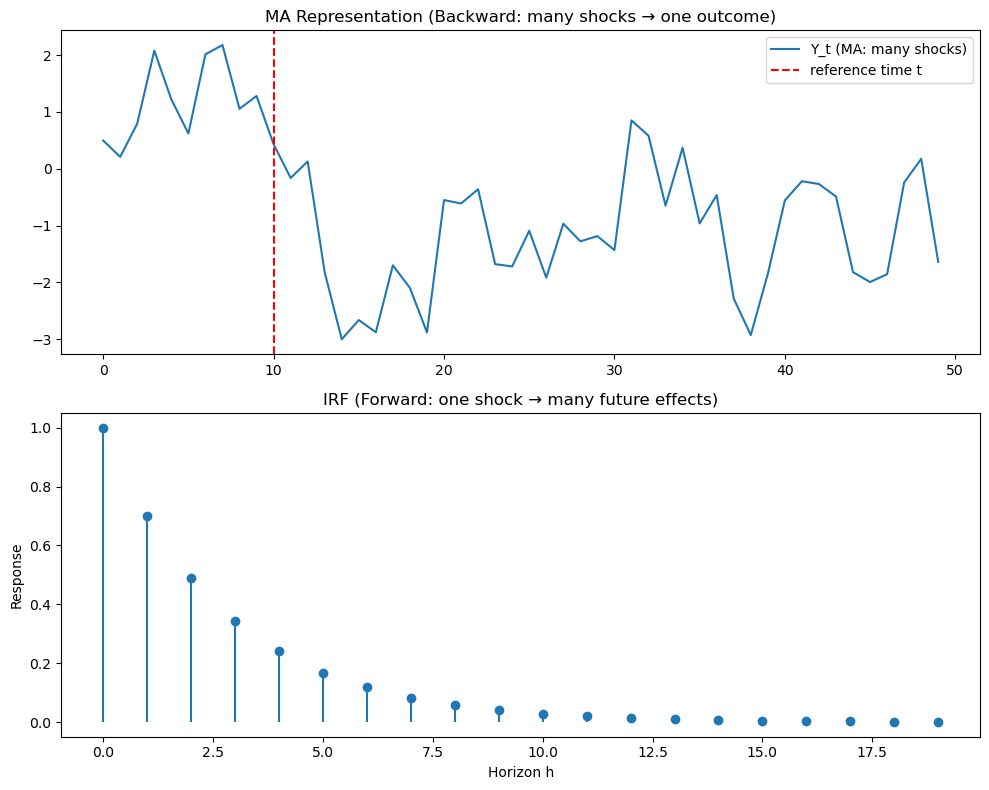

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Define a simple AR(1) model
# ----------------------------
phi = 0.7          # persistence parameter
T = 50             # sample size
np.random.seed(42)

# Generate shocks (epsilon_t)
eps = np.random.normal(0, 1, T)

# ----------------------------
# 2. Construct MA coefficients C_h
# For AR(1): C_h = phi^h
# ----------------------------
H = 20  # horizon
C = np.array([phi**h for h in range(H)])

# ----------------------------
# 3. MA representation (backward-looking)
# Y_t = sum C_h * eps_{t-h}
# ----------------------------
Y_ma = np.zeros(T)

for t in range(T):
    for h in range(min(t+1, H)):
        Y_ma[t] += C[h] * eps[t - h]

# ----------------------------
# 4. IRF (forward-looking)
# Fix ONE shock at time t0
# ----------------------------
t0 = 10
shock_size = 1

irf = np.zeros(H)
for h in range(H):
    irf[h] = C[h] * shock_size  # Y_{t+h} = C_h * eps_t

# ----------------------------
# 5. Plot results
# ----------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# MA plot
ax[0].plot(Y_ma, label="Y_t (MA: many shocks)")
ax[0].set_title("MA Representation (Backward: many shocks → one outcome)")
ax[0].axvline(t0, color='red', linestyle='--', label="reference time t")
ax[0].legend()

# IRF plot
ax[1].stem(range(H), irf, basefmt=" ")
ax[1].set_title("IRF (Forward: one shock → many future effects)")
ax[1].set_xlabel("Horizon h")
ax[1].set_ylabel("Response")

plt.tight_layout()
plt.show()

### Interpretation of MA vs IRF

**Top panel (MA representation):**  
Each value of $(Y_t)$ is the result of **many past shocks combined together**.  
The series looks irregular because multiple shocks from different times overlap.

 *Many shocks → one outcome*

---

**Bottom panel (IRF):**  
Shows the effect of **one single shock** over time.  
The response starts large and **gradually decays**, reflecting persistence $(C_h = \phi^h)$.




$ \phi $ measures **persistence**.

- $ Y_t = \phi Y_{t-1} + \varepsilon_t $
- Larger $ \phi $ → shocks last longer  
- Smaller $ \phi $ → shocks fade quickly  

In IRF: $ C_h = \phi^h $

 *One shock → many future effects*

 
---

**Key takeaway:**  
The MA plot shows the **realized data (mixture of shocks)**, while the IRF isolates the **dynamic effect of a single shock**.



<h2 style="background-color: #FDEDEC; padding: 8px;"> Appendix: Impulse Response Recursion
</h2>


### 🔹 Definition

The impulse response at horizon $h$ is defined as:

$$
C_h = \frac{\partial y_{t+h}}{\partial \varepsilon_t}
$$

**Meaning:**  
It measures how a one-unit shock at time $t$ affects the system $h$ periods ahead.

---

### 🔹 VAR($p$) Model

$$
y_t = \sum_{\ell=1}^{p} A_\ell y_{t-\ell} + \varepsilon_t
$$

This is the **law of motion** of the system.

---

### 🔹 Derivation of the Recursion

Move one step forward:

$$
y_{t+h} = \sum_{\ell=1}^{p} A_\ell y_{t+h-\ell} + \varepsilon_{t+h}
$$

Take derivative with respect to the original shock $\varepsilon_t$:

$$
\frac{\partial y_{t+h}}{\partial \varepsilon_t}
=
\sum_{\ell=1}^{p} A_\ell \frac{\partial y_{t+h-\ell}}{\partial \varepsilon_t}
$$

Since future shocks are independent:

$$
\frac{\partial \varepsilon_{t+h}}{\partial \varepsilon_t} = 0 \quad \text{for } h>0
$$

---

### 🔹 Recursion Formula

$$
C_h = \sum_{\ell=1}^{\min(h,p)} A_\ell C_{h-\ell}
$$

---

### 🔹 Why $\min(h, p)$?

- If $h < p$: some terms like $C_{h-\ell}$ do not exist  
- If $h \ge p$: all $p$ lags are available  

So we only sum over **valid lags**.

---

### 🔹 Intuition

The response at horizon $h$ is obtained by propagating past responses through the system dynamics.

- $A_\ell$: transmission mechanism  
- $C_{h-\ell}$: past responses  

The system reuses its past to generate the future.

---

### 🔹 Initial Condition

$$
C_0 = I
$$

The shock affects the system instantaneously.

---

### 🔹 Example (VAR(3), $h=5$)

$$
C_5 = A_1 C_4 + A_2 C_3 + A_3 C_2
$$

---

### 🔹 One-line Summary

Impulse responses are computed recursively by applying the VAR dynamics forward to the initial shock.

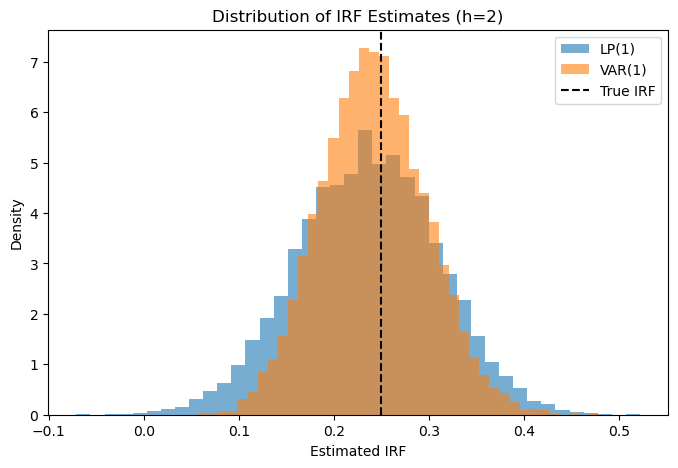

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Parameters ---
T = 240              # sample size
Nsim = 10000          # number of simulations
rho = 0.5           # AR(1) coefficient
h = 2                # horizon

true_irf = rho**h    # true impulse response

lp_estimates = []
var_estimates = []

for sim in range(Nsim):

    # --- Generate data ---
    y = np.zeros(T)
    eps = np.random.normal(size=T)

    for t in range(1, T):
        y[t] = rho * y[t-1] + eps[t]

    # --- LP estimation ---
    y_h = y[h:]                     # y_{t+h}
    x = y[:-h]                      # y_t
    X = sm.add_constant(x)

    model_lp = sm.OLS(y_h, X).fit()
    theta_lp = model_lp.params[1]
    lp_estimates.append(theta_lp)

    # --- VAR(1) estimation ---
    Y = y[1:]
    X_var = y[:-1]
    X_var = sm.add_constant(X_var)

    model_var = sm.OLS(Y, X_var).fit()
    rho_hat = model_var.params[1]

    theta_var = rho_hat**h
    var_estimates.append(theta_var)

# --- Convert to arrays ---
lp_estimates = np.array(lp_estimates)
var_estimates = np.array(var_estimates)

# --- Plot ---
plt.figure(figsize=(8,5))

plt.hist(lp_estimates, bins=40, alpha=0.6, label='LP(1)', density=True)
plt.hist(var_estimates, bins=40, alpha=0.6, label='VAR(1)', density=True)

plt.axvline(true_irf, color='black', linestyle='--', label='True IRF')

plt.xlabel('Estimated IRF')
plt.ylabel('Density')
plt.title(f'Distribution of IRF Estimates (h={h})')
plt.legend()

plt.show()

<h2 style="background-color: #FDEDEC; padding: 8px;">
Appendix: Sampling Variance and Long-Run Variance in LP-IV
</h2>

---

## 1. What is Sampling Variance?

In econometrics, we estimate a parameter (e.g., $\beta_h$) using data. Because the data is random, our estimate $\hat{\beta}_h$ is also random.

The **sampling variance** measures:

$$
Var(\hat{\beta}_h) = \text{how much the estimator varies across different samples}
$$

---

### Intuition

If we repeated the experiment many times:

$$
\hat{\beta}_h^{(1)}, \hat{\beta}_h^{(2)}, \dots
$$

then:

$$
Var(\hat{\beta}_h) = E\left[(\hat{\beta}_h - \beta_h)^2\right]
$$

---

## 2. IV Estimator in LP-IV

The IV (Wald) estimator is:

$$
\hat{\beta}_h =
\frac{\frac{1}{T} \sum_{t=1}^T Z_t Y_{i,t+h}}
{\frac{1}{T} \sum_{t=1}^T Z_t Y_{1,t}}
$$

### Key Points

- “Wald” refers to a method of estimating or testing parameters using ratios of moments (or estimates).
- It is mainly associated with IV (and GMM), not with OLS estimation itself.
- A Wald test evaluates hypotheses using $(\text{estimate} - \text{hypothesized value})$ relative to its variance to test a parameter.

---

## 3. Structural Model

Assume:

$$
Y_{i,t+h} = \beta_h Y_{1,t} + u_{i,t+h}
$$

Multiply both sides by $Z_t$:

$$
Z_t Y_{i,t+h} = \beta_h Z_t Y_{1,t} + Z_t u_{i,t+h}
$$

---

## 4. Key Moment Condition

Under IV assumptions:

$$
E(Z_t u_{i,t+h}) = 0
$$

---

## 5. Asymptotic Distribution

As $T \to \infty$:

$$
\sqrt{T}(\hat{\beta}_h - \beta_h)
\;\xrightarrow{d}\;
\mathcal{N}\left(0,\;
\frac{\Omega_h}{(E[Z_t Y_{1,t}])^2}
\right)
$$

---

## 6. Definition of $\Omega_h$ (Long-Run Variance)

Let:

$$
v_t = Z_t u_{i,t+h}
$$

Then:

$$
\Omega_h =
\lim_{T \to \infty}
Var\left( \frac{1}{\sqrt{T}} \sum_{t=1}^T v_t \right)
$$

---

## 7. Expanding the Variance

$$
Var\left( \frac{1}{\sqrt{T}} \sum_{t=1}^T v_t \right)
=
\frac{1}{T} \sum_{t=1}^T \sum_{s=1}^T Cov(v_t, v_s)
$$

---

## 8. Using Stationarity

Let $k = t - s$:

$$
\Omega_h =
\sum_{k=-\infty}^{\infty}
Cov(v_t, v_{t-k})
$$

---

## 9. Substitute Back

Since $v_t = Z_t u_{i,t+h}$:

$$
\Omega_h =
\sum_{k=-\infty}^{\infty}
Cov\left(Z_t u_{i,t+h},\; Z_{t-k} u_{i,t-k+h}\right)
$$

---

## 10. Decomposition

$$
\Omega_h =
\underbrace{Var(Z_t u_{i,t+h})}_{k=0}
+
\sum_{k \neq 0}
Cov(Z_t u_{i,t+h}, Z_{t-k} u_{i,t-k+h})
$$

---

## 11. Special Case (No Serial Correlation)

If $v_t$ is not autocorrelated:

$$
\Omega_h = Var(Z_t u_{i,t+h})
$$

---

## 12. Expand the Variance Term

Since $E(Z_t u_{i,t+h}) = 0$:

$$
Var(Z_t u_{i,t+h}) = E[Z_t^2 u_{i,t+h}^2]
$$

---

## 13. Final Expression for Sampling Variance

$$
Var(\hat{\beta}_h) =
\frac{\Omega_h}{(E[Z_t Y_{1,t}])^2}
$$

---

## 14. Role of Control Variables

Suppose we add controls $W_t$:

$$
Y_{i,t+h} = \beta_h Y_{1,t} + \gamma W_t + \tilde{u}_{i,t+h}
$$

By projection:

$$
Var(\tilde{u}_{i,t+h}) \leq Var(u_{i,t+h})
$$

---

### Effect on $\Omega_h$

$$
\Omega_h^{controls} =
\sum_{k} Cov(Z_t \tilde{u}_{i,t+h}, Z_{t-k} \tilde{u}_{i,t-k+h})
$$

Since residual variance decreases:

$$
\Omega_h^{controls} < \Omega_h
$$

---

## 15. Final Insight

$$
Var(\hat{\beta}_h) \propto \Omega_h
\quad \text{and} \quad
\Omega_h \propto Var(u_{i,t+h})
$$

---

## ✅ Key Takeaway

- Sampling variance measures uncertainty in $\hat{\beta}_h$
- It depends on the **long-run variance** of $Z_t u_{i,t+h}$
- Adding controls reduces $Var(u)$, which reduces $\Omega_h$
- Therefore, controls improve **efficiency (precision)** but not identification